# EJERCICIO 1 EDA PYTHON

#### 1.- Carga todos los csv en un único dataframe. ¿Cuantas filas totales obtienes?

In [2]:
import pandas as pd

df19 = pd.read_csv("2019_Accidentalidad.csv", sep=";")
df20 = pd.read_csv("2020_Accidentalidad.csv", sep=";")
df21 = pd.read_csv("2021_Accidentalidad.csv", sep=";")
df22 = pd.read_csv("2022_Accidentalidad.csv", sep=";")
df23 = pd.read_csv("2023_Accidentalidad.csv", sep=";")
df24 = pd.read_csv("2024_Accidentalidad.csv", sep=";")
df25 = pd.read_csv("2025_Accidentalidad.csv", sep=";")


df = pd.concat([df19, df20, df21, df22, df23, df24, df25], ignore_index=True, sort=False)

print(f"Número total de filas: {len(df.index)}")

Número total de filas: 312980


#### 2.- No vamos a emplear variable que estén referidas a las coordenadas, borra todas aquellas columnas que estén referidas a coordenadas.

In [ ]:
df = df.drop(["coordenada_x_utm", "coordenada_y_utm"], axis=1)

#### 3.- Si observamos la columna que contiene el tipo de vehículo, encontramos mucha información redundante, vamos a reestructurar esta columna para tener solamente las siguientes categorías: 'Turismo', 'Motocicleta', 'Furgoneta', 'Bicicleta', 'Camión', 'Autobús', 'Otro vehículo'.

In [4]:
turismos = ["Todo terreno", "Turismo"]
motos = [
    "Ciclo de motor L1e-A", "Ciclomotor", "Ciclomotor de dos ruedas L1e-B", 
    "Ciclomotor de tres ruedas", "Cuadriciclo ligero", "Cuadriciclo no ligero", 
    "Moto de tres ruedas > 125cc", "Moto de tres ruedas hasta 125cc", 
    "Motocicleta > 125cc", "Motocicleta hasta 125cc"
]
furgonetas = ["Furgoneta"]
bicis = ["Ciclo", "Bicicleta", "Bicicleta EPAC (pedaleo asistido)"]
camiones = ["Tractocamión", "Vehículo articulado", "Camión de bomberos", "Camión rígido"]
autobuses = ["Microbús <= 17 plazas", "Autobus EMT", "Autobús", "Autobús articulado", "Autobús articulado EMT"]
otros = [
    "Maquinaria agrícola", "Maquinaria de obras", "Otros vehículos con motor", 
    "Otros vehículos sin motor", "Remolque", "Patinete", "Patinete no eléctrico", 
    "Semiremolque", "Sin especificar", "Tranvía", "Tren/metro", "VMU eléctrico", 
    "Ambulancia SAMUR", "Autocaravana", "Caravana"
]

In [5]:
nuevo_tipo_vehiculo = {}
for v in turismos: nuevo_tipo_vehiculo[v] = "Turismo"
for v in motos: nuevo_tipo_vehiculo[v] = "Motocicleta"
for v in furgonetas: nuevo_tipo_vehiculo[v] = "Furgonetas"
for v in bicis: nuevo_tipo_vehiculo[v] = "Bicicletas"
for v in camiones: nuevo_tipo_vehiculo[v] = "Camiones"
for v in autobuses: nuevo_tipo_vehiculo[v] = "Autobuses"
for v in otros: nuevo_tipo_vehiculo[v] = "Otro Vehículo"

df["tipo_vehiculo"] = df["tipo_vehiculo"].map(nuevo_tipo_vehiculo).fillna("Otro Vehículo")

#### 4.- Para el resto de columnas, vamos a analizar valores nulos, inspecciona los valores nulos de todas las columnas.

In [6]:
df.isnull().sum() / len(df.index) * 100

num_expediente           0.000000
fecha                    0.000000
hora                     0.000000
localizacion             0.000000
numero                   0.002556
cod_distrito             0.002556
distrito                 0.002556
tipo_accidente           0.002876
estado_meteorológico    11.023708
tipo_vehiculo            0.000000
tipo_persona             0.000959
rango_edad               0.000000
sexo                     0.000000
cod_lesividad           45.045690
lesividad               45.045690
positiva_alcohol         0.356572
positiva_droga          99.676337
dtype: float64

In [7]:
# Rellenar los valores nulos en la columna "positiva_droga" con "0"

df["positiva_droga"] = df["positiva_droga"].fillna("0")
df["positiva_droga"].head()

0    0
1    0
2    0
3    0
4    0
Name: positiva_droga, dtype: object

In [8]:
# Rellenar los valores nulos en la columna "positiva_alcohol" con "N"

df["positiva_alcohol"] = df["positiva_alcohol"].fillna("N")
df["positiva_alcohol"].head()

0    N
1    N
2    S
3    N
4    N
Name: positiva_alcohol, dtype: object

In [9]:
# Rellenar los valores nulos en la columna "cod_lesividad" con "0"

df["cod_lesividad"] = df["cod_lesividad"].fillna("0")
df["cod_lesividad"].head()

0    7.0
1    7.0
2      0
3      0
4      0
Name: cod_lesividad, dtype: object

In [10]:
# Rellenar los valores nulos en la columna "lesividad" con "Sin atención sanitaria"

df["lesividad"] = df["lesividad"].fillna("Sin atención sanitaria")
df["lesividad"].head()

0    Asistencia sanitaria sólo en el lugar del acci...
1    Asistencia sanitaria sólo en el lugar del acci...
2                               Sin atención sanitaria
3                               Sin atención sanitaria
4                               Sin atención sanitaria
Name: lesividad, dtype: object

In [11]:
# Rellenar los valores nulos en la columna "estado_meteorológico" con "Se desconoce"

df["estado_meteorológico"] = df["estado_meteorológico"].fillna("Se desconoce")
df["estado_meteorológico"].head()

0       Despejado
1       Despejado
2    Se desconoce
3    Se desconoce
4    Se desconoce
Name: estado_meteorológico, dtype: object

In [12]:
df.isnull().sum() / len(df.index) * 100

num_expediente          0.000000
fecha                   0.000000
hora                    0.000000
localizacion            0.000000
numero                  0.002556
cod_distrito            0.002556
distrito                0.002556
tipo_accidente          0.002876
estado_meteorológico    0.000000
tipo_vehiculo           0.000000
tipo_persona            0.000959
rango_edad              0.000000
sexo                    0.000000
cod_lesividad           0.000000
lesividad               0.000000
positiva_alcohol        0.000000
positiva_droga          0.000000
dtype: float64

In [13]:
# ELiminar el resto de valores nulos del reso del DataFrame

df = df.dropna()
df.isnull().sum() / len(df.index) * 100

num_expediente          0.0
fecha                   0.0
hora                    0.0
localizacion            0.0
numero                  0.0
cod_distrito            0.0
distrito                0.0
tipo_accidente          0.0
estado_meteorológico    0.0
tipo_vehiculo           0.0
tipo_persona            0.0
rango_edad              0.0
sexo                    0.0
cod_lesividad           0.0
lesividad               0.0
positiva_alcohol        0.0
positiva_droga          0.0
dtype: float64

In [14]:
# Número total de filas y columnas

print(f"Número total de filas y columnas: {df.shape}")

Número total de filas y columnas: (312960, 17)


#### 5.- Vamos a seguir reduciendo el número de categorías de las columnas categóricas, en este caso, vamos a generar una nueva categoría llamada "Otro accidente" para todas aquellas categorías que tengan un porcentaje inferior al 10% en la columna tipo accidente.

In [15]:
porcentaje = df["tipo_accidente"].value_counts(normalize=True) * 100
otros_accidentes = porcentaje[porcentaje < 10]
df["tipo_accidente"] = df["tipo_accidente"].replace(otros_accidentes.index, "Otro accidente")
df["tipo_accidente"].value_counts(normalize=True) * 100

tipo_accidente
Colisión fronto-lateral         25.403246
Otro accidente                  24.017766
Alcance                         23.790261
Colisión lateral                14.916922
Choque contra obstáculo fijo    11.871805
Name: proportion, dtype: float64

#### 6.- Dentro de la gravedad de un accidente de tráfico como estamos comprobando hay conductores que dieron positivo por alcohol y, otros positivos por consumo de droga, pero ¿Hay algún accidente en donde los implicados dieran positivo en la prueba de alcohol y también en la prueba de drogas? Muestra el número de implicados, así como el número de expedientes diferentes.

In [16]:
print("Valores en alcohol:", df["positiva_alcohol"].unique())
print("Valores en droga:", df["positiva_droga"].unique())
print("Tipo de dato en droga:", df["positiva_droga"].dtype)

# ha sido necesario ejecutar estos prints para entender con que valor 
# es necesario hacer el filtro para obtener los resultados correctod

Valores en alcohol: ['N' 'S']
Valores en droga: ['0' 1.0]
Tipo de dato en droga: object


In [ ]:
positivos = df[(df["positiva_alcohol"]=="S") & (df["positiva_droga"]==1)]
implicados = len(positivos)
expedientes = positivos["num_expediente"].nunique()

print(f"El número de implicados es de {implicados}")
print(f"El número de expedientes es de {expedientes}")

El número de implicados es de 205
El número de expedientes es de 201


#### 7.- ¿Cuál es el tipo de accidente más común para aquellos implicados que habían dado positivo en alcohol? ¿y para aquellos implicados que no dieron positivo en la prueba de alcohol? ¿Qué diferencias observas?

In [18]:
df_alcohol_si = df[df["positiva_alcohol"]=="S"]
df_alcohol_no = df[df["positiva_alcohol"]=="N"]

accidente_top_si = df_alcohol_si["tipo_accidente"].value_counts().idxmax()
accidente_top_no = df_alcohol_no["tipo_accidente"].value_counts().idxmax()

print(f"El tipo de accidente más común para aquellos implicados POSITIVOS en alcohol es: {accidente_top_si}")
print(f"El tipo de accidente más común para aquellos implicados NEGATIVOS en alcohol es: {accidente_top_no}")

El tipo de accidente más común para aquellos implicados POSITIVOS en alcohol es: Choque contra obstáculo fijo
El tipo de accidente más común para aquellos implicados NEGATIVOS en alcohol es: Colisión fronto-lateral


In [19]:
df_alcohol_si["tipo_accidente"].value_counts()

tipo_accidente
Choque contra obstáculo fijo    3352
Otro accidente                  1839
Alcance                         1723
Colisión fronto-lateral         1290
Colisión lateral                 767
Name: count, dtype: int64

In [20]:
df_alcohol_no["tipo_accidente"].value_counts()

tipo_accidente
Colisión fronto-lateral         78212
Otro accidente                  73327
Alcance                         72731
Colisión lateral                45917
Choque contra obstáculo fijo    33802
Name: count, dtype: int64

```
Se puede observar una diferencia en el tipo de accidente más común entre los dos grupos. Aquellos que dieron positivo en alcohol tienen una mayor incidencia de accidentes tipo "Choque contra obstáculo fijo", mientras que aquellos que no dieron positivo en alcohol tienen una mayor incidencia de accidentes tipo "Colisión fronto-lateral". Aprovechando el conteo de tipos de accidentes, se puede observar que existen muchos más accidentes en el grupo de no positivos en alcohol en comparación con el grupo de positivos en alcohol.
```

#### 8.- Para cada tipo de vehículo muestra visualmente el número de accidentes en función del estado meteorológico. 

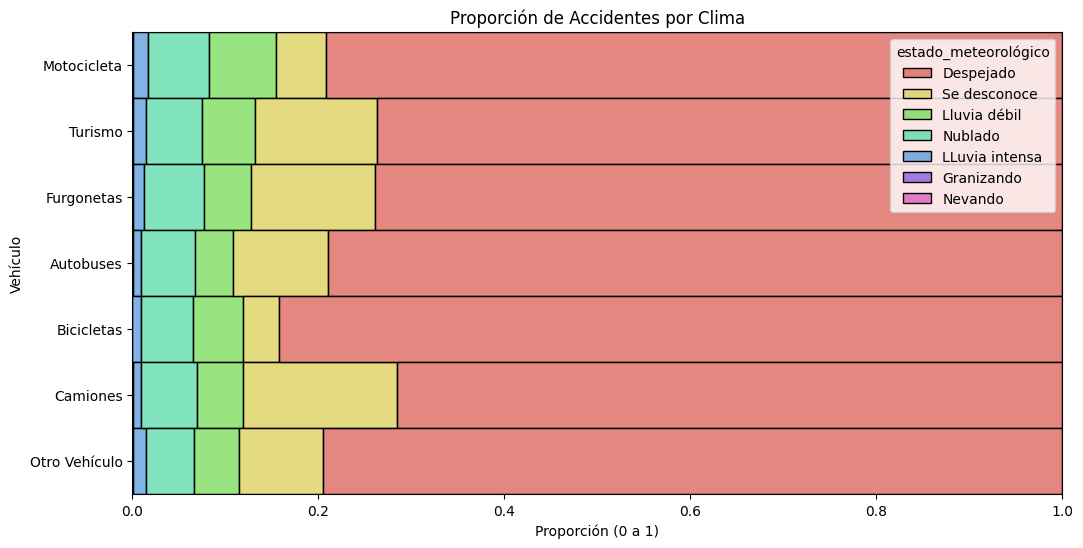

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.histplot(data=df, y="tipo_vehiculo", hue="estado_meteorológico", multiple="fill", palette="hls")

plt.title("Proporción de Accidentes por Clima")
plt.xlabel("Proporción (0 a 1)")
plt.ylabel("Vehículo")
plt.show()

#### 9.- Agrupa el dataframe por el número de expediente, vamos a analizar si hay accidentes múltiples. De la agrupación anterior obtén todos aquellos números de expediente que tengan involucrados mayor o igual que 5 tipos distintos de vehículos ¿Cuántos números de expediente aparecen? ¿Qué cantidad de implicados hay en cada expediente? Qué tipos de vehículos diferentes aparecen encada número de expediente?

In [22]:
resumen_expedientes = df.groupby("num_expediente").agg(
    implicados=("num_expediente", "count"),
    n_tipos_vehiculo=("tipo_vehiculo", "nunique"),
    lista_vehiculos=("tipo_vehiculo", "unique")
)

resultado_expedientes = resumen_expedientes[resumen_expedientes["n_tipos_vehiculo"] >= 5]
resultado_expedientes

,implicados,n_tipos_vehiculo,lista_vehiculos
num_expediente,,,
2022S022123,10,5,"[Camiones, Furgonetas, Motocicleta, Otro Vehíc..."


In [ ]:
print(f"El número de expediente con al menos 5 tipos de vehículos involucrados es: {len(resultado_expedientes)}")
print(f"La cantidad de implicados por expediente es de : {resultado_expedientes["implicados"].values[0]}")
print(f"Los diferentes tipos de vehículos involucrados son: {resultado_expedientes["lista_vehiculos"].values[0]}")

El número de expediente con al menos 5 tipos de vehículos involucrados es: 1
La cantidad de implicados por expediente es de : 10
Los diferentes tipos de vehículos involucrados son: ['Camiones' 'Furgonetas' 'Motocicleta' 'Otro Vehículo' 'Turismo']


#### 10.- Toma la columna hora y, quédate solamente la hora, es decir de 9:10:00 solo obtener 09, tras ello, muestra gráficamente cuáles son las horas más peligrosas para circular en Madrid.

In [24]:
df["hora_accidente"] = df["hora"].str.split(":").str[0].astype(int)

In [25]:
df["hora_accidente"].head()

0    9
1    9
2    3
3    3
4    3
Name: hora_accidente, dtype: int64

In [26]:
df["hora_accidente"].tail()

312975    21
312976    21
312977    20
312978    19
312979    19
Name: hora_accidente, dtype: int64

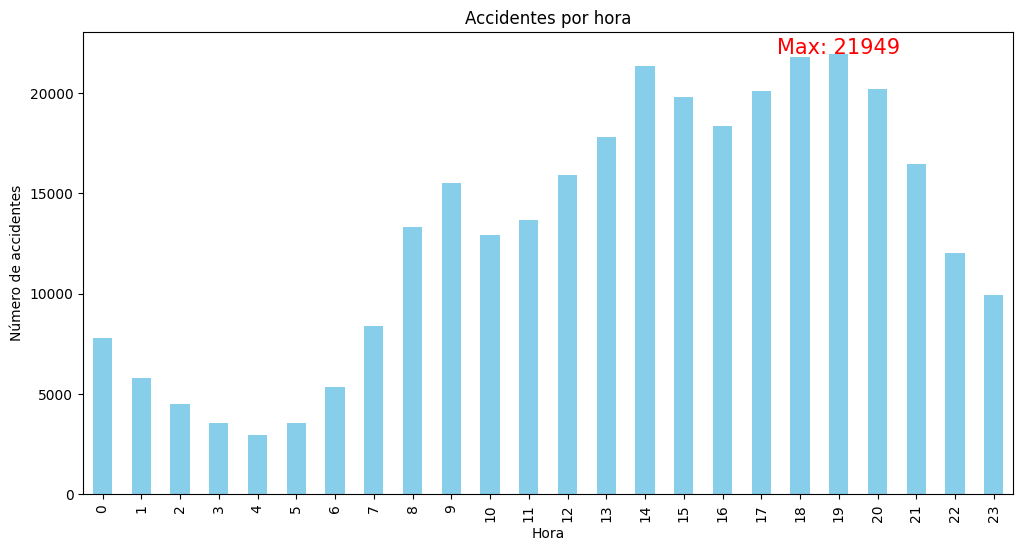

In [27]:
plt.figure(figsize=(12, 6))

grafico_horas = df["hora_accidente"].value_counts().sort_index()
grafico_horas.plot(kind="bar", color="skyblue")

plt.text(grafico_horas.idxmax(), grafico_horas.max(), f"Max: {grafico_horas.max()}", ha="center", color="red", fontsize=15)

plt.title("Accidentes por hora")
plt.xlabel("Hora")
plt.ylabel("Número de accidentes")

plt.show()